<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week15/Intro_to_NLP_W15D1_ExerciseXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 15. Intro to NLP preprocessing

https://octopus.developers.institute/courses/collection/124/course/726/section/1973/chapter/3754

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 80.7 MB/s eta 0:00:00


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [27]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str, prt: bool = False) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review.

    Args:
        text (str): The input text to preprocess.
        prt (bool, optional): If True, intermediate steps will be printed. Defaults to False.

    Returns:
        str: The cleaned and preprocessed text.
    """
    # 1. Lowercase and tokenize the text
    tokens = nltk.word_tokenize(text.lower())
    if prt:
        print(f"\nTokens after lowercasing and tokenization: {tokens}")

    # 2. Remove punctuation tokens
    tokens_no_punct = [token for token in tokens if token not in string.punctuation]
    if prt:
        print(f"Tokens after punctuation removal: {tokens_no_punct}")

    # 3. Filter out stopwords
    tokens_no_stopwords = [token for token in tokens_no_punct if token not in stop_words]
    if prt:
        print(f"Tokens after stopword removal: {tokens_no_stopwords}")

    # 4. Lemmatize remaining tokens
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens_no_stopwords]
    if prt:
        print(f"Tokens after lemmatization: {lemmatized_tokens}")

    # 5. Join back into a single cleaned string
    cleaned_text = " ".join(lemmatized_tokens)
    if prt:
        print(f"Cleaned text: {cleaned_text}")

    return cleaned_text

In [28]:
#Print the processed reviews to confirm every stage works.
print(f"Original review: {raw_reviews[5]}")
processed_review = preprocess_text(raw_reviews[5], prt = True)
print(f"\nProcessed review: {processed_review}")


Original review: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.

Tokens after lowercasing and tokenization: ['the', 'ambiance', 'at', 'bella', 'italia', 'is', 'amazing', ',', 'and', 'the', 'pasta', 'dishes', 'are', 'delicious', '.']
Tokens after punctuation removal: ['the', 'ambiance', 'at', 'bella', 'italia', 'is', 'amazing', 'and', 'the', 'pasta', 'dishes', 'are', 'delicious']
Tokens after stopword removal: ['ambiance', 'bella', 'italia', 'amazing', 'pasta', 'dishes', 'delicious']
Tokens after lemmatization: ['ambiance', 'bella', 'italia', 'amazing', 'pasta', 'dish', 'delicious']
Cleaned text: ambiance bella italia amazing pasta dish delicious

Processed review: ambiance bella italia amazing pasta dish delicious


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [29]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = []
for review in raw_reviews:
    cleaned_review = preprocess_text(review)
    cleaned_reviews.append(cleaned_review)

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [31]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # 1. run the spaCy pipeline on the text
    doc = nlp(text)

    # 2. collect each entity text and its label_
    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return entities

In [32]:
for i, review in enumerate(raw_reviews):
    print(f"\nReview {i+1}: {review}")
    detected_entities = perform_ner(review)
    if detected_entities:
        print(f"  Entities: {detected_entities}")
    else:
        print("  No entities detected.")


Review 1: At McDonald's the food was ok and the service was bad.
  Entities: [('McDonald', 'ORG')]

Review 2: I would not recommend this Japanese restaurant to anyone.
  Entities: [('Japanese', 'NORP')]

Review 3: I loved this restaurant when I traveled to Thailand last summer.
  Entities: [('Thailand', 'GPE'), ('last summer', 'DATE')]

Review 4: The menu of Loving has a wide variety of options.
  Entities: [('Loving', 'GPE')]

Review 5: The staff was friendly and helpful at Google's employees restaurant.
  Entities: [('Google', 'ORG')]

Review 6: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
  Entities: [('Bella Italia', 'ORG')]

Review 7: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
  Entities: [('Pizza Hut', 'ORG')]

Review 8: The sushi at Sushi Express is always fresh and flavorful.
  Entities: [('Sushi Express', 'ORG')]

Review 9: The steakhouse on Main Street has a cozy atmosphere and excellent steaks.
  

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [41]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = word_tokenize(text)
    # TODO: call nltk.pos_tag on the tokens
    pos_tags = pos_tag(tokens)
    return pos_tags


In [44]:
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw} \n {perform_pos_tagging(raw)}")
    print(f"CLEANED: {cleaned}\n{perform_pos_tagging(cleaned)}\n")

RAW: At McDonald's the food was ok and the service was bad. 
 [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
CLEANED: mcdonald 's food ok service bad
[('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]

RAW: I would not recommend this Japanese restaurant to anyone. 
 [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]
CLEANED: would recommend japanese restaurant anyone
[('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]

RAW: I loved this restaurant when I traveled to Thailand last summer. 
 [('I', 'PRP'), ('loved', 'VBD'), ('this', 'DT'), ('restaurant', 'NN'), ('when', 'WRB'), ('I', 'PRP'), ('traveled', 'VBD'), ('to', 'TO

In [38]:
import nltk
nltk.download('tagsets_json', quiet=True)

print("\n--- Understanding POS Tags ---")
# Use nltk.help.upenn_tagset to recall tag meanings
nltk.help.upenn_tagset('NN') # Singular noun
nltk.help.upenn_tagset('NNS') # Plural noun
nltk.help.upenn_tagset('VBD') # Verb, past tense
nltk.help.upenn_tagset('JJ') # Adjective


--- Understanding POS Tags ---
NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...
NNS: noun, common, plural
    undergraduates scotches bric-a-brac products bodyguards facets coasts
    divestitures storehouses designs clubs fragrances averages
    subjectivists apprehensions muses factory-jobs ...
VBD: verb, past tense
    dipped pleaded swiped regummed soaked tidied convened halted registered
    cushioned exacted snubbed strode aimed adopted belied figgered
    speculated wore appreciated contemplated ...
JJ: adjective or numeral, ordinal
    third ill-mannered pre-war regrettable oiled calamitous first separable
    ectoplasmic battery-powered participatory fourth still-to-be-named
    multilingual multi-disciplinary ...


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [49]:
sample_texts = raw_reviews[:2]

print("NER on raw text")
#  loop through sample_texts and print perform_ner results
for i, review in enumerate(sample_texts):
    print(f"\nReview {i+1}: {review}")
    print(f"  Entities: {perform_ner(review)}")
    #  repeat using cleaned_reviews
    print(f"  Cleaned: {preprocess_text(review)}")
    #POS tags on raw text
    print(f"  POS tags on raw text: {perform_pos_tagging(review)}")
    #POS tags on cleaned text
    print(f"  POS tags on cleaned text: {perform_pos_tagging(preprocess_text(review))}")



NER on raw text

Review 1: At McDonald's the food was ok and the service was bad.
  Entities: [('McDonald', 'ORG')]
  Cleaned: mcdonald 's food ok service bad
  POS tags on raw text: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
  POS tags on cleaned text: [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]

Review 2: I would not recommend this Japanese restaurant to anyone.
  Entities: [('Japanese', 'NORP')]
  Cleaned: would recommend japanese restaurant anyone
  POS tags on raw text: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]
  POS tags on cleaned text: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]


## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [50]:
from gensim.models import Word2Vec

# ensure cleaned_reviews is defined from Exercise 1
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# train the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,  # Dimensionality of the word vectors
    window=5,         # Maximum distance between the current and predicted word
    min_count=1,      # Ignores all words with total frequency lower than this
    sg=1,             # Training algorithm: 1 for skip-gram, 0 for CBOW
    epochs=10         # Number of training iterations
)
w2v_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [51]:
# print the vector size and vocabulary size of your model
print(f"Vector size: {w2v_model.wv.vector_size}")
print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")

Vector size: 100
Vocabulary size: 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

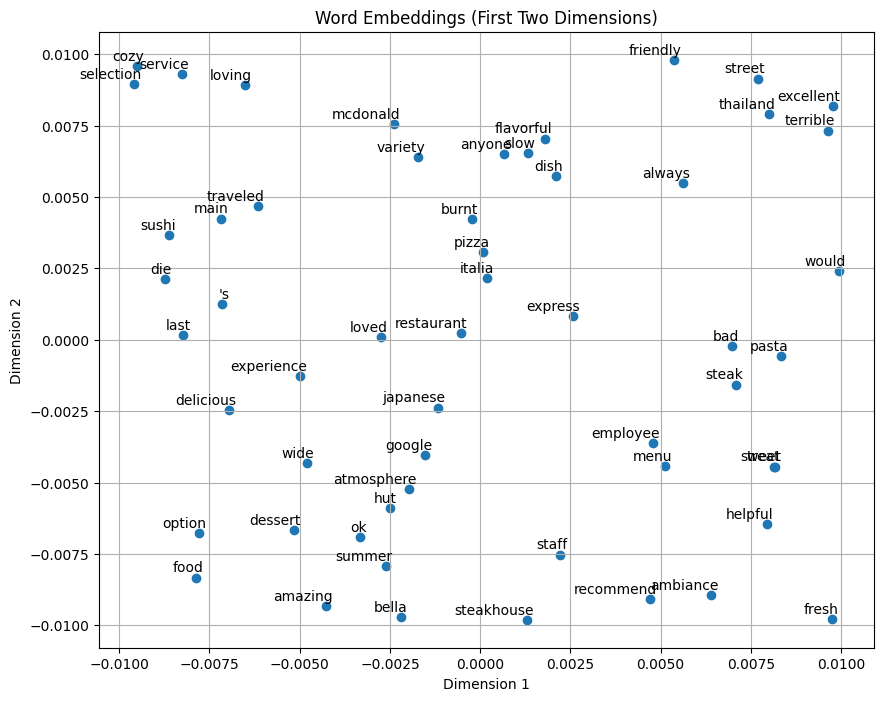

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
    if words is None:
        words = list(model.wv.index_to_key)

    vectors = np.array([model.wv[word] for word in words])

    plt.figure(figsize=(10, 8))
    plt.scatter(vectors[:, 0], vectors[:, 1])

    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors[i, 0], vectors[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('Word Embeddings (First Two Dimensions)')
    plt.grid(True)
    plt.show()

# TODO: call the plotting function using your trained model
plot_word_embeddings(w2v_model)

The words 'excellent' and 'terrible' are closest to each other because they mean the same characteristic. Also, 'pizza' and 'italia' aren't far from each other. This suggests that the Word2Vec model has learned meaningful relationships between words based on their usage in the reviews.

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

### Experiment 1: Bigrams

Bigrams are contiguous sequences of two words. They can capture more context than single words.

In [53]:
from nltk.util import ngrams

# one of the cleaned reviews
sample_cleaned_review = cleaned_reviews[0]

# Tokenize the cleaned review to generate bigrams
# The preprocess_text function joins tokens back, so we need to re-tokenize for ngrams
tokens_for_bigrams = sample_cleaned_review.split()

# Generate bigrams
bigrams_list = list(ngrams(tokens_for_bigrams, 2))

print(f"Original cleaned review: {sample_cleaned_review}")
print(f"Bigrams: {bigrams_list}")

Original cleaned review: mcdonald 's food ok service bad
Bigrams: [('mcdonald', "'s"), ("'s", 'food'), ('food', 'ok'), ('ok', 'service'), ('service', 'bad')]


### Experiment 2: Stemming vs. Lemmatization

The current `preprocess_text` function uses lemmatization. Create a new function that uses stemming to compare the outputs. Stemming is a more aggressive process that chops off suffixes, often resulting in non-dictionary words, while lemmatization aims to return the base or dictionary form of a word.

In [58]:
from nltk.stem import PorterStemmer
import string

# Initialize the stemmer
stemmer = PorterStemmer()

# Reusing stop_words set from earlier

def preprocess_text_stemming(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and stem a review."""
    tokens = nltk.word_tokenize(text.lower())
    tokens_no_punct = [token for token in tokens if token not in string.punctuation]
    tokens_no_stopwords = [token for token in tokens_no_punct if token not in stop_words]
    stemmed_tokens = [stemmer.stem(token) for token in tokens_no_stopwords]
    return " ".join(stemmed_tokens)

# Compare outputs for a sample review
sample_raw_review = raw_reviews[5]
lemmatized_output = preprocess_text(sample_raw_review)
stemmed_output = preprocess_text_stemming(sample_raw_review)

print(f"Original review: {sample_raw_review}")
print(f"Lemmatized output: {lemmatized_output}")
print(f"Stemmed output: {stemmed_output}")

# Apply to all reviews and display first few comparisons
stemmed_reviews = [preprocess_text_stemming(review) for review in raw_reviews]

print("\n--- Comparison for all reviews (first 3) ---")
for i in range(3):
    print(f"Raw: {raw_reviews[i]}")
    print(f"Lemmatized: {cleaned_reviews[i]}")
    print(f"Stemmed: {stemmed_reviews[i]}\n")

Original review: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
Lemmatized output: ambiance bella italia amazing pasta dish delicious
Stemmed output: ambianc bella italia amaz pasta dish delici

--- Comparison for all reviews (first 3) ---
Raw: At McDonald's the food was ok and the service was bad.
Lemmatized: mcdonald 's food ok service bad
Stemmed: mcdonald 's food ok servic bad

Raw: I would not recommend this Japanese restaurant to anyone.
Lemmatized: would recommend japanese restaurant anyone
Stemmed: would recommend japanes restaur anyon

Raw: I loved this restaurant when I traveled to Thailand last summer.
Lemmatized: loved restaurant traveled thailand last summer
Stemmed: love restaur travel thailand last summer



###  Tune Word2Vec Hyperparameters

A new Word2Vec model with different hyperparameters and comparing its embeddings. Increasing `vector_size` and `window`.

In [55]:
from gensim.models import Word2Vec

# Train a new Word2Vec model with tuned hyperparameters
w2v_model_tuned = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=200,  # Increased vector size
    window=10,        # Increased window size
    min_count=1,
    sg=1,
    epochs=20         # Increased epochs
)

print(f"Tuned Model - Vector size: {w2v_model_tuned.wv.vector_size}")
print(f"Tuned Model - Vocabulary size: {len(w2v_model_tuned.wv.key_to_index)}")

Tuned Model - Vector size: 200
Tuned Model - Vocabulary size: 56


### Plot Tuned Word Embeddings

Visualizing the embeddings from the new, tuned model and comparing them to the previous plot.

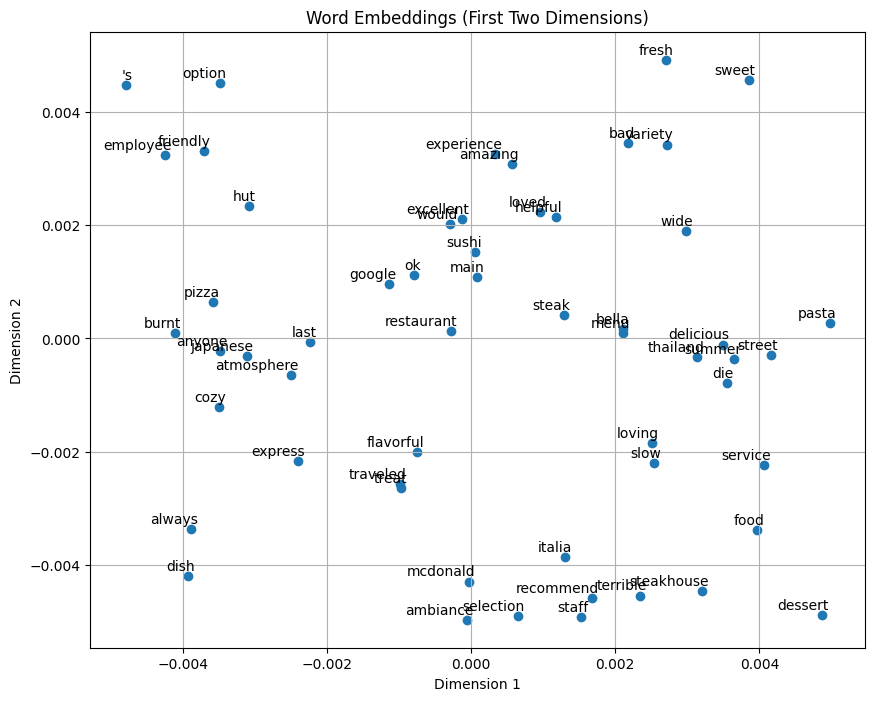

In [56]:
plot_word_embeddings(w2v_model_tuned)

The second plot shows a deeper connection between word pairs: 'friendly' 'employee', 'amazing' 'experience'

### Dimensionality Reduction with t-SNE

To get a richer visualization of the word embeddings, especially with higher dimensional vectors, it's possible to use dimensionality reduction techniques like t-SNE (t-Distributed Stochastic Neighbor Embedding). t-SNE is particularly good at preserving local structures in the data, making it suitable for visualizing clusters.

Applying t-SNE to the embeddings from  `w2v_model_tuned` and plot the results.

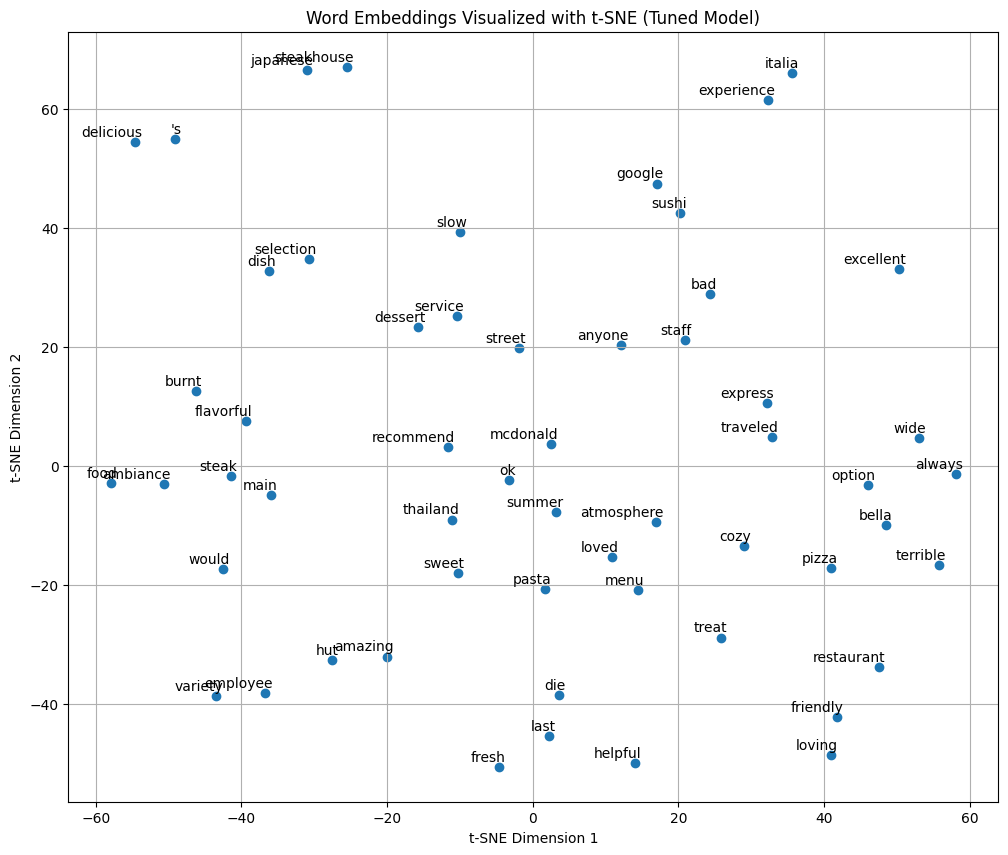

In [57]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Get words and their vectors from the tuned model
words = list(w2v_model_tuned.wv.index_to_key)
vectors = np.array([w2v_model_tuned.wv[word] for word in words])

# Apply t-SNE to reduce to 2 dimensions
tsne_model = TSNE(perplexity=min(len(words)-1, 5), n_components=2, random_state=42, init='pca', learning_rate='auto')
two_dim_vectors = tsne_model.fit_transform(vectors)

# Plot the t-SNE results
plt.figure(figsize=(12, 10))
plt.scatter(two_dim_vectors[:, 0], two_dim_vectors[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(two_dim_vectors[i, 0], two_dim_vectors[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('Word Embeddings Visualized with t-SNE (Tuned Model)')
plt.grid(True)
plt.show()

The t-SNE plot helps us visualize the relationships between words in a reduced 2D space. Words that are semantically similar should appear closer together. But to be honest, I can't confirm the existence of any clear clusters representing groups of related terms from the reviews.